# Flower Color Images — Load, Visualize & Augment

## Step 1 

In [11]:
FLOWER_DIR = 'flower/flower_images/flower_images'

## Step 2 — Install Libraries

In [2]:
!pip install tensorflow keras pillow -q

## Step 3 — Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
import random
import os
from scipy.ndimage import rotate
from PIL import Image

## Step 4 — Load & Display 5 Random Flower Images

<Figure size 2000x500 with 0 Axes>

<Figure size 2000x500 with 0 Axes>

<Figure size 2000x500 with 0 Axes>

<Figure size 2000x500 with 0 Axes>

<Figure size 2000x500 with 0 Axes>

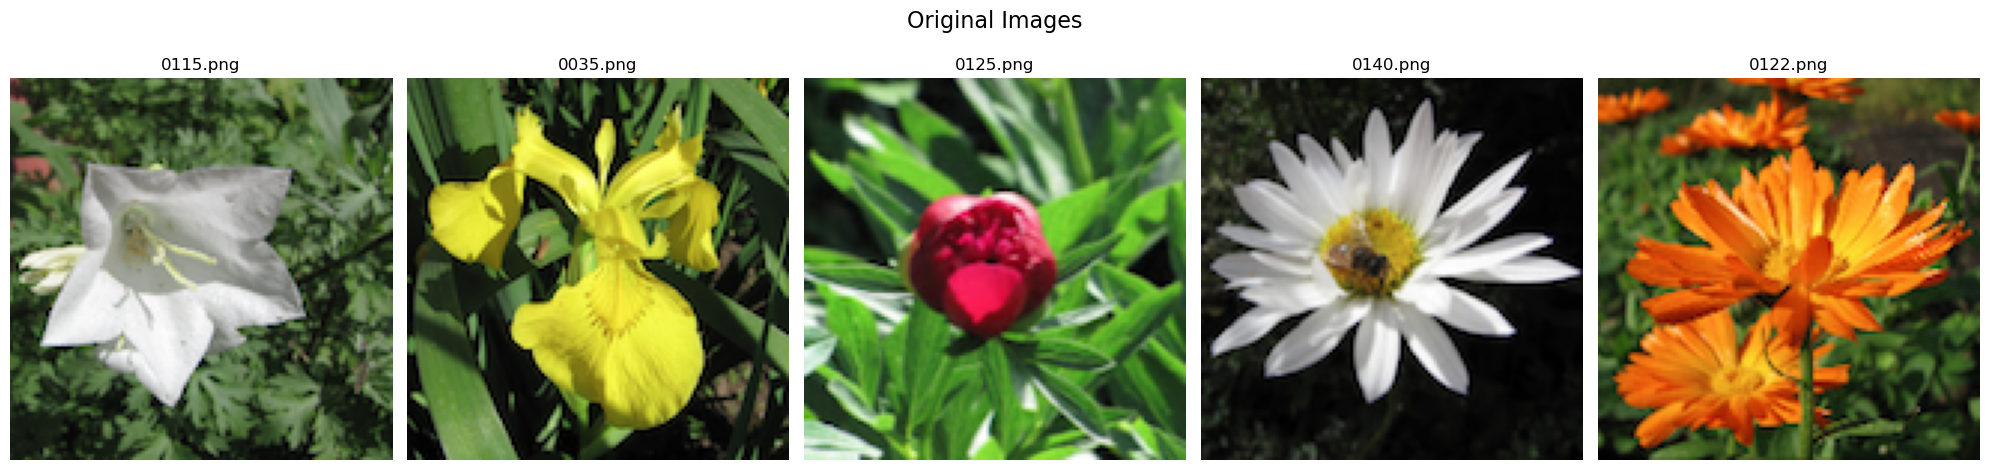

In [12]:
list_img = []
list_files = []

plt.figure(figsize=(20, 5))
for i in range(5):
    file = random.choice(os.listdir(FLOWER_DIR))
    image_path = os.path.join(FLOWER_DIR, file)
    img = mpimg.imread(image_path)
    list_img.append(img)
    list_files.append(file)

for i, img in enumerate(list_img):
    ax = plt.subplot(1, 5, i + 1)
    ax.title.set_text(list_files[i])
    plt.imshow(img)
    plt.axis('off')

plt.suptitle('Original Images', fontsize=16)
plt.tight_layout()
plt.show()

## Step 5 — Augmentation Functions

In [17]:
# --- Rotate by 90 degrees ---
def rotate_image_90_degrees(image):
    return rotate(image, angle=90, reshape=False, mode='nearest')

# --- Flip horizontally ---
def flip_horizontal(image):
    return np.fliplr(image)

# --- Flip vertically ---
def flip_vertical(image):
    return np.flipud(image)

# --- Zoom in 1.2x using PIL resize ---
def zoom_image(image, scale=1.2):
    # Convert float image to uint8 if needed
    if image.dtype == np.float32 or image.dtype == np.float64:
        img_uint8 = (image * 255).astype(np.uint8)
    else:
        img_uint8 = image.astype(np.uint8)
    
    pil_img = Image.fromarray(img_uint8)
    orig_w, orig_h = pil_img.size
    # Resize to larger size
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)
    zoomed = pil_img.resize((new_w, new_h), Image.BILINEAR)
    # Crop back to original size (center crop)
    left = (new_w - orig_w) // 2
    top  = (new_h - orig_h) // 2
    zoomed = zoomed.crop((left, top, left + orig_w, top + orig_h))
    # Convert back to float in range [0, 1]
    return np.array(zoomed).astype(np.float32) / 255

## Step 6 — Visualize All Augmentations Side by Side

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.817416e-17..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.3809075e-17..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.5119725e-17..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9.072899e-17..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9.016674e-17..1.0].


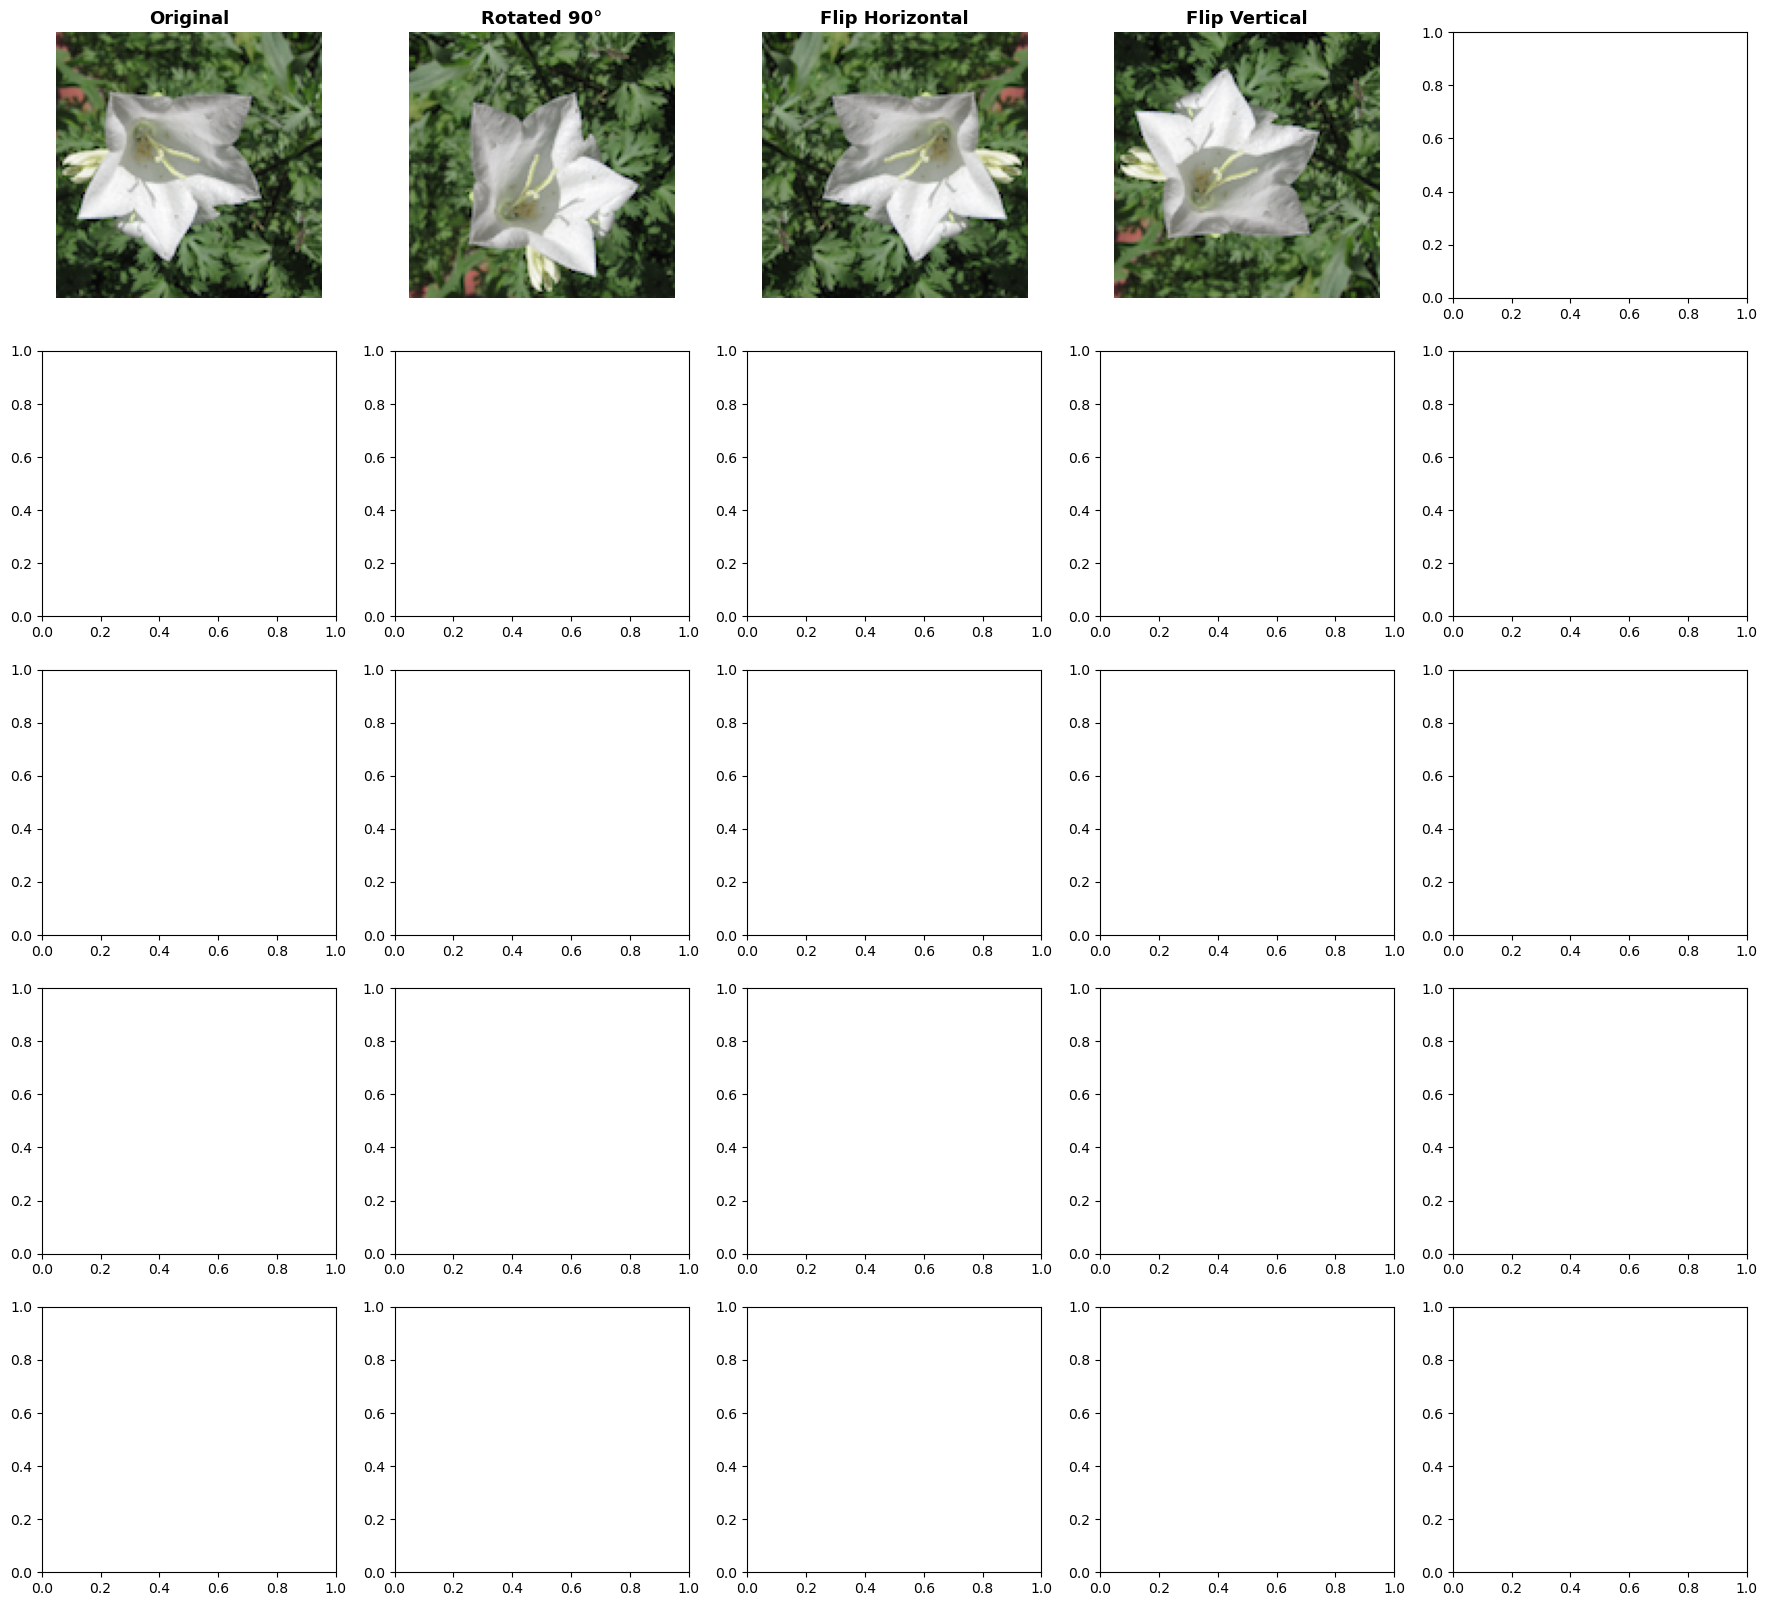

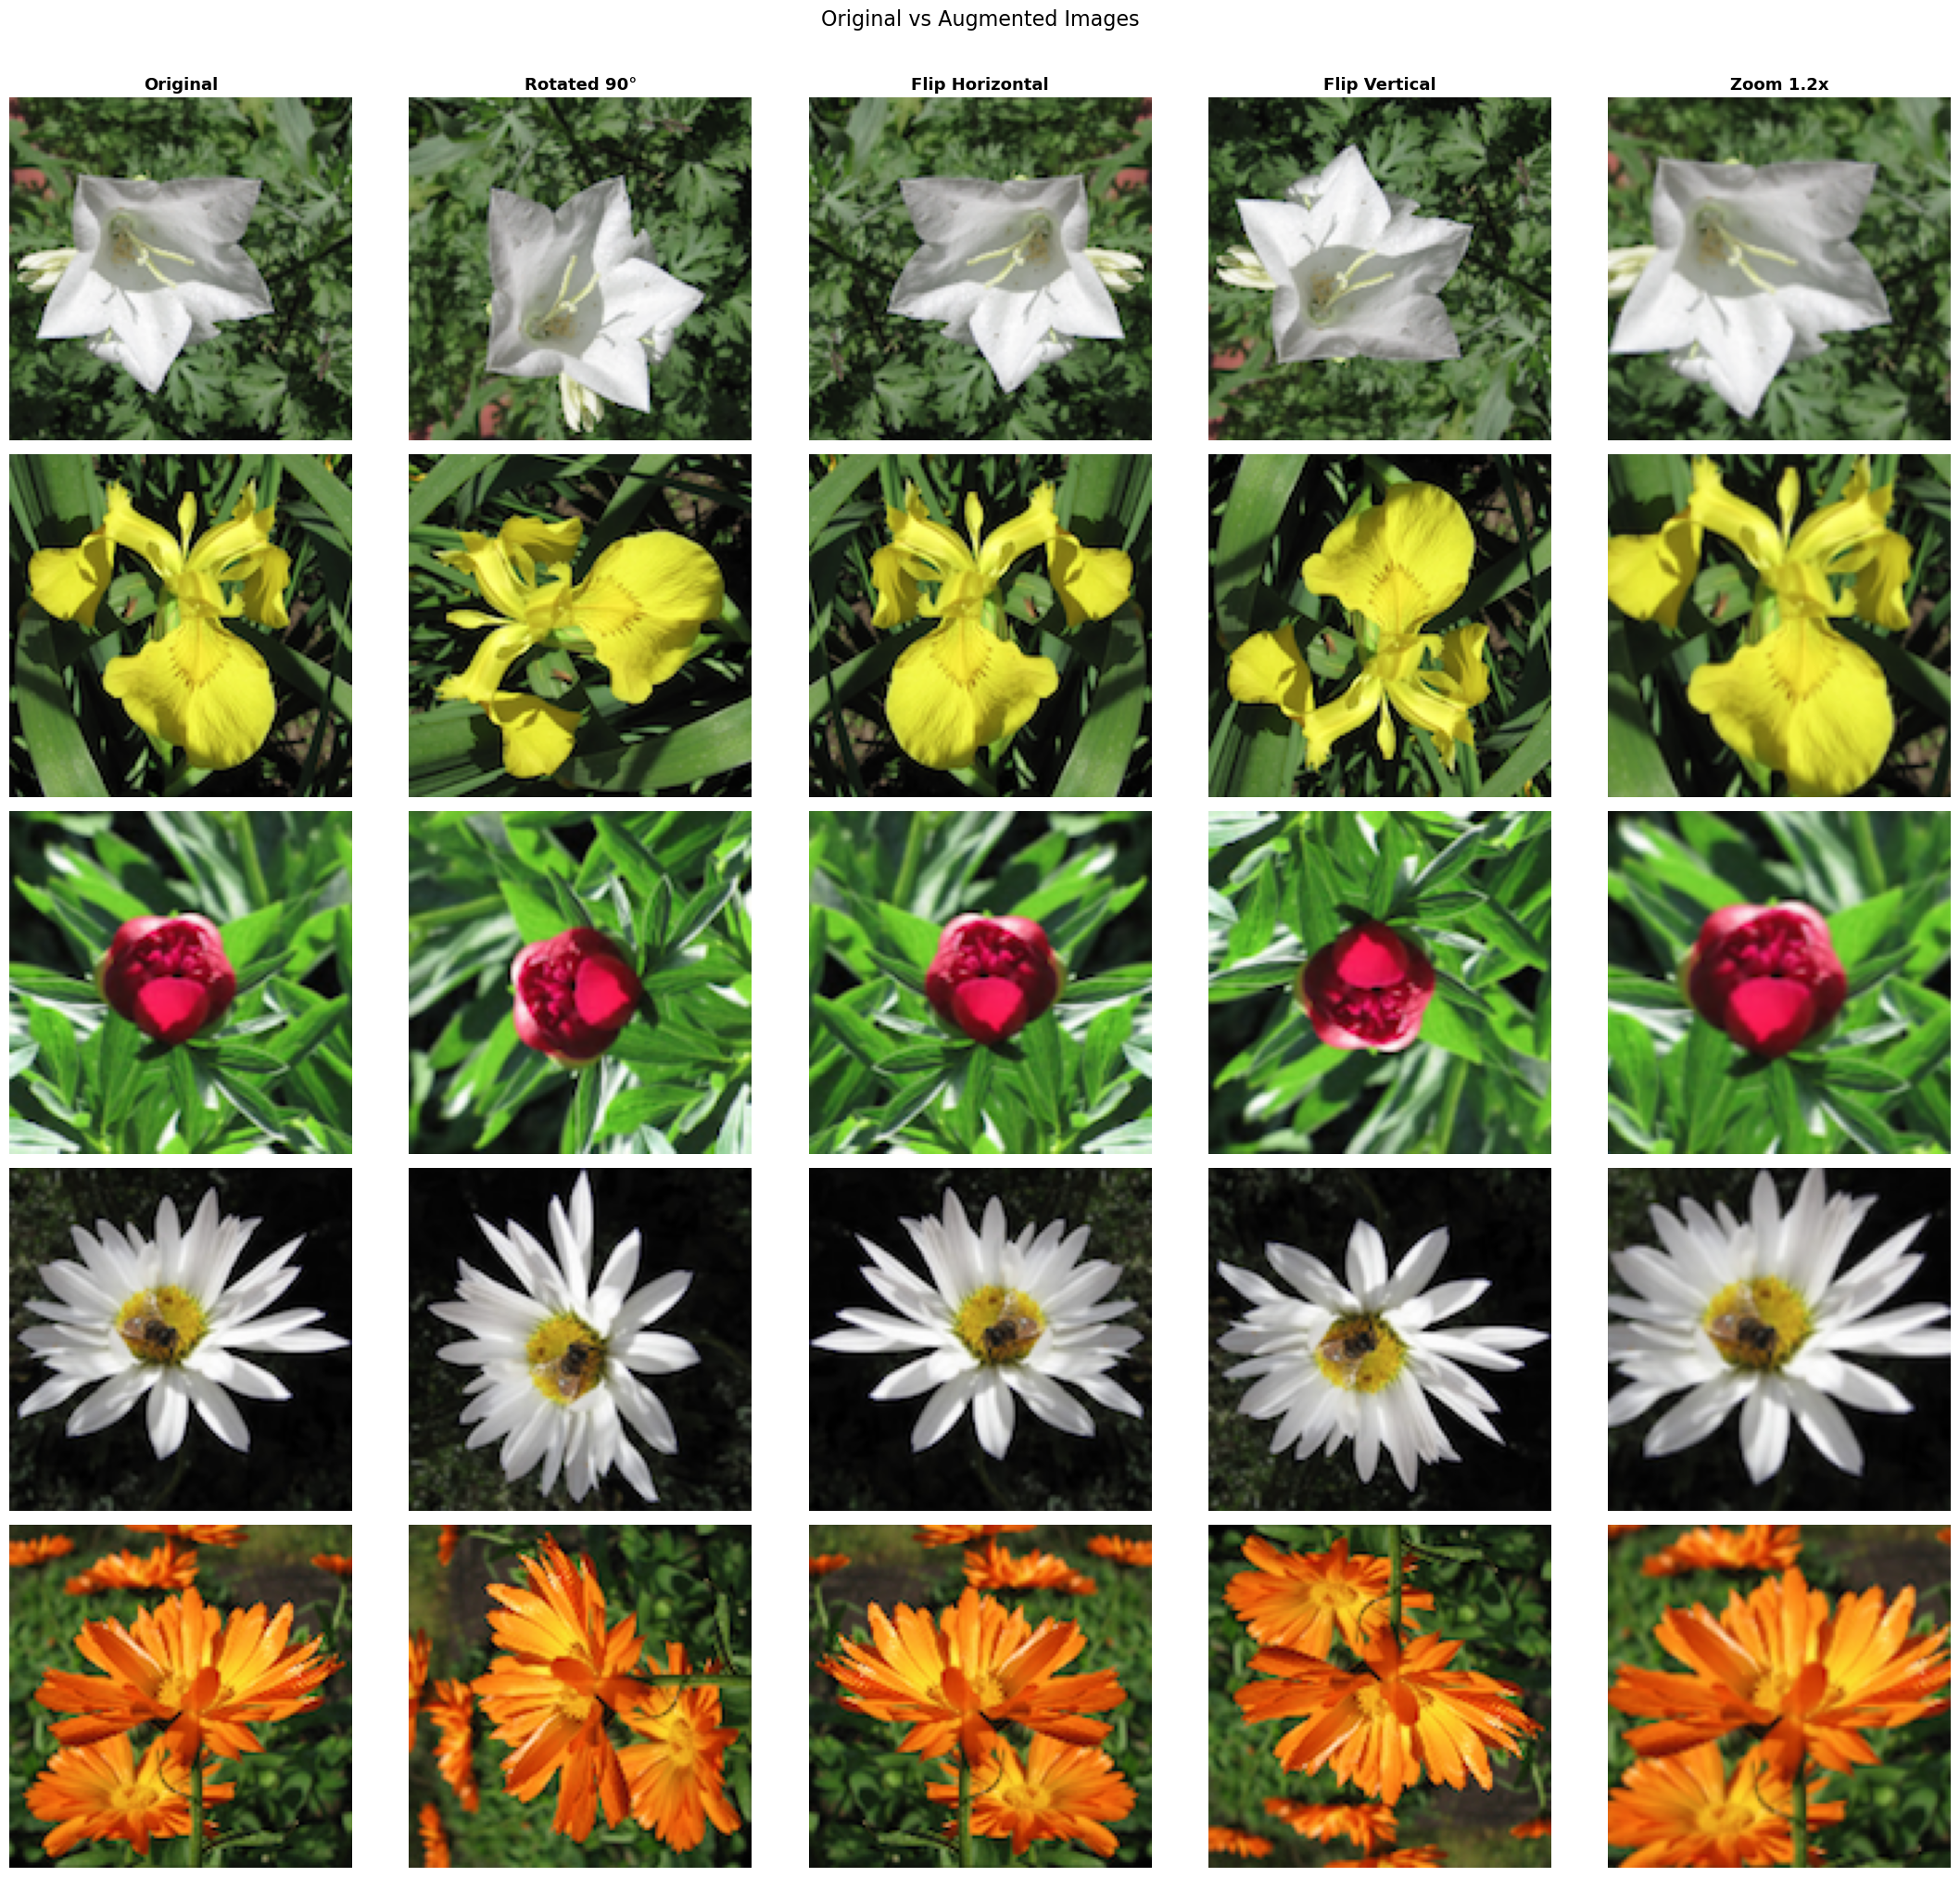

In [16]:
n = len(list_img)  # 5 images
aug_labels = ['Original', 'Rotated 90°', 'Flip Horizontal', 'Flip Vertical', 'Zoom 1.2x']
aug_funcs  = [lambda x: x, rotate_image_90_degrees, flip_horizontal, flip_vertical, zoom_image]

fig, axes = plt.subplots(n, 5, figsize=(22, 4 * n))

for row, img in enumerate(list_img):
    for col, (label, fn) in enumerate(zip(aug_labels, aug_funcs)):
        aug = fn(img)
        axes[row, col].imshow(aug)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(label, fontsize=13, fontweight='bold')

plt.suptitle('Original vs Augmented Images', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## Step 7 — Visualize Rotated Images (original display loop)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.817416e-17..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.3809075e-17..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.5119725e-17..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9.072899e-17..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9.016674e-17..1.0].


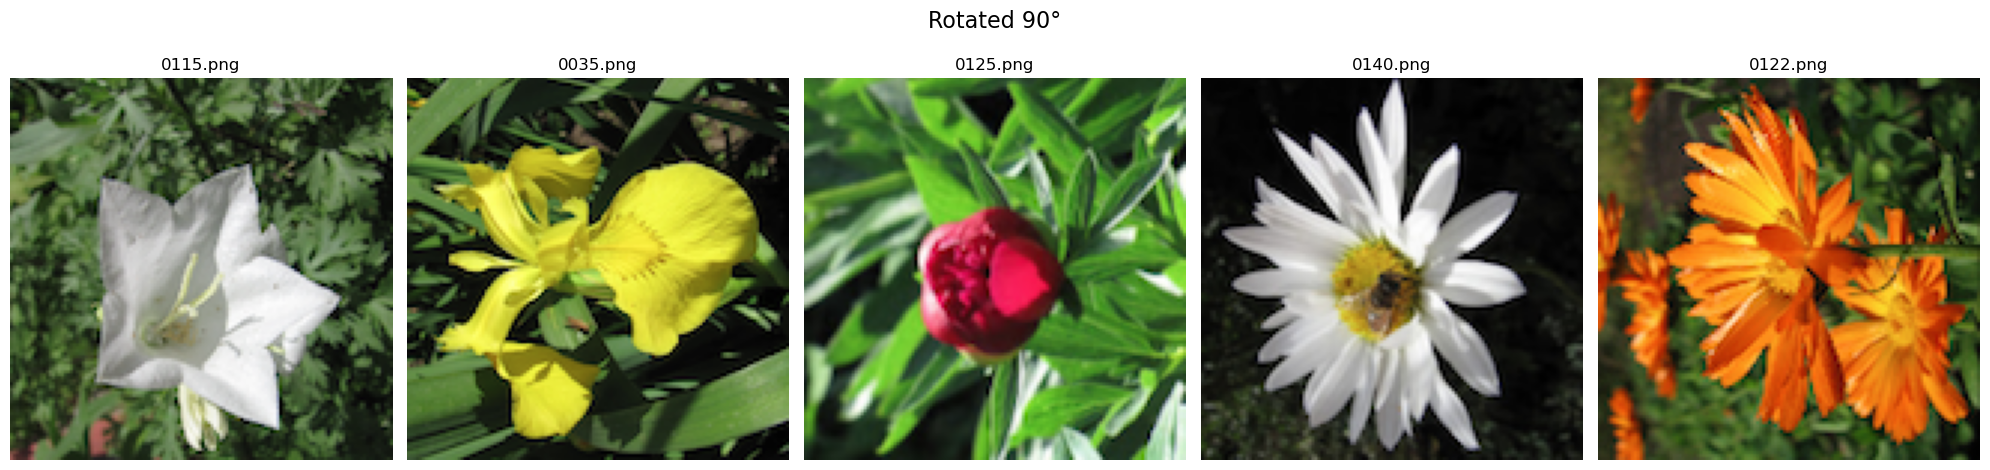

In [18]:
rotated_list = [rotate_image_90_degrees(img) for img in list_img]

plt.figure(figsize=(20, 5))
for i, img in enumerate(rotated_list):
    ax = plt.subplot(1, 5, i + 1)
    ax.title.set_text(list_files[i])
    plt.imshow(img)
    plt.axis('off')

plt.suptitle('Rotated 90°', fontsize=16)
plt.tight_layout()
plt.show()